# Exploratory Data Analysis
## Gas Monitoring & Activity Level Classification

**Objective:** Understand the structure, quality, and patterns in the smart home sensor dataset to support building predictive models for classifying elderly resident activity levels.

**Dataset:** `gas_monitoring.db` — environmental sensor readings from elderly residents' homes.

**Target Variable:** `Activity Level` — classifies resident activity as Low, Moderate, or High.

---
### EDA Processses
1. Data Loading & Initial Inspection
2. Data Quality Assessment
3. Data Cleaning, Standardisation & Sanitizing 
4. Univariate Analysis
5. Bivariate Analysis (Features vs Target)
6. Correlation & Multicollinearity Analysis
7. Session-Level Analysis
8. Summary & Implications for Modelling

---
## Setup
Import all EDA functions from `EDAPython.py`.

In [1]:
from src.EDAPython import *

---
## Part 1: Data Import and Review

**Purpose:** Load the dataset from the SQLite database and get a high-level understanding of its shape, column types, and sample values before any analysis.

We use SQLite3 to connect and Pandas to load the data into a DataFrame.

In [2]:
# Importing all the necessary items
import sqlite3
import pandas as pd

# Importing the data
data_path = '/app/data/gas_monitoring.db'
conn = sqlite3.connect(data_path)
query = "SELECT * FROM gas_monitoring"
df_raw = pd.read_sql_query(query, conn)

conn.close()
df_raw.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [3]:
# Display the top 5 columns of the dataset
df_raw.head(5)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [4]:
# Display the data type of each column
df_raw.dtypes

Time of Day                   object
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                 float64
Session ID                     int64
HVAC Operation Mode           object
Ambient Light Level           object
Activity Level                object
dtype: object

**In Conclusion**
- The dataset has **10,000 rows** and **14 columns**: 9 continuous sensor readings (as seen categorized as the **float64**), 4 categorical columns (as seen categorized as the **str**), and 1 integer session ID (as seen categorized as the **int64**).

---
## Part 2: Data Quality Assessment

**Purpose:** Identify missing values, duplicate rows, and label inconsistencies as the problem statement mentioned and warned that the dataset may contain *synthetic or contaminated data*. Therefore, in order to perceive the best data output, data quality checking is needed.

The things we will be checking are:
- Missing values per column
- Duplicate rows
- Label noise in categorical columns (e.g. mixed casing, typos)

=== Missing Values ===
                        Missing Count  Missing %
Humidity                         1928      19.28
MetalOxideSensor_Unit2           1410      14.10
CO_GasSensor                      834       8.34
Ambient Light Level              1054      10.54

=== Duplicate Rows ===
  171 duplicate rows found


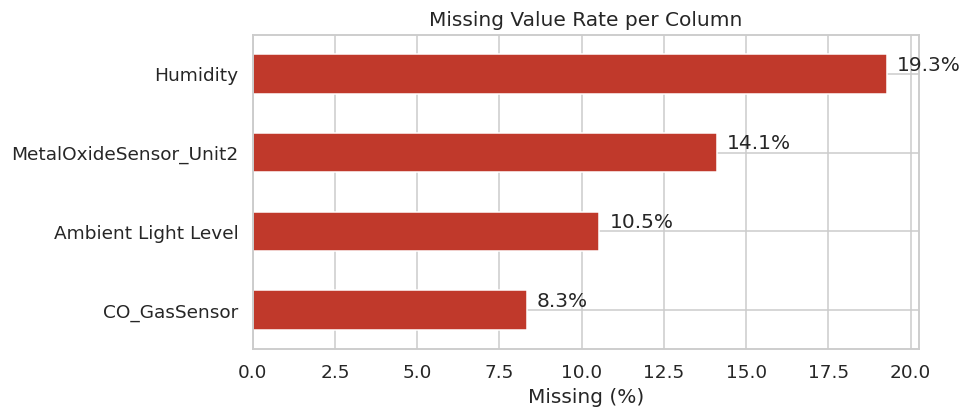


=== Raw Activity Level values ===
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238

=== Raw HVAC Operation Mode values ===
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
VENTILATION_ONLY      98
HEATING_ACTIVE        98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44

=== Physical Boundary Violations ===
  CO2_InfraredSensor negative values : 113 rows (min=-17.47 ppm)
  CO2_InfraredSensor mean            : 109.86 ppm (expec

In [5]:
# Function from Python file
check_quality(df_raw)

**Why certain values are physically impossible:**

| Feature | Invalid Range | Why its impossible |
|---|---|---|
| Humidity | < 0% or > 100% | Relative humidity is a percentage — it cannot go below absolute dryness (0%) or above fully liquid air (100%) |
| CO2_InfraredSensor | < 0 ppm | Gas concentration cannot be negative — matter cannot have negative presence |
| CO2_InfraredSensor | mean ~109 ppm | Earth's outdoor baseline is ~420 ppm — a room at 109 ppm would be uninhabitable |
| Temperature | > 100°C | Indoor temperature cannot exceed boiling point under normal conditions |

**References:**
- (https://www.who.int/publications/i/item/9789240034228) — establishes physical baselines for humidity (0–100% RH) and gas concentrations
- (https://gml.noaa.gov/ccgg/trends/) — outdoor CO2 baseline is ~420 ppm; values below this indoors are physically impossible
- (https://www.ashrae.org/technical-resources/bookstore/standard-55-thermal-environmental-conditions-for-human-occupancy) — defines acceptable indoor temperature (18–26°C) and humidity (30–60% RH) ranges

**In Conclusion**
- **4 columns have missing values:** `Humidity` (~19% = 1900/10000), `MetalOxideSensor_Unit2` (~14% = 1400/10000), `Ambient Light Level` (~11% = 1100/10000), `CO_GasSensor` (~8% = 800/10000).
- **No duplicate rows** detected.
- **Significant label noise** found in `Activity Level` — certain values such as `Low_Activity`, `LowActivity`, `ModerateActivity` are inconsistent spellings of the same class.
- **HVAC Operation Mode** also has mixed casing — all the different variants may refer to the same category.

**What we have done:** All label variants are mapped to their canonical form. HVAC labels normalised to lowercase with underscores.

---
## Part 3: Data Cleaning & Standardisation

**Purpose:** Apply all the corrections identified in Step 2, and handle temperature outliers (readings outside 10–40°C are physically implausible for an indoor living space) which can affect the data reading.

What we will do:
- Standardise all categorical labels
- Replace implausible temperature values with column median
- Impute missing numeric values with median
- Fill missing `Ambient Light Level` with mode

In [6]:
# Apply all the cleaning steps in the python file to the raw data
df = clean_data(df_raw)

Temperature outliers : 864 rows  (range before: 6.9 – 307.1 C)
  Replaced with median: 20.21 C
  Imputed Humidity with median = 51.39
  Imputed MetalOxideSensor_Unit2 with median = 726.75
  Imputed CO_GasSensor with median = 1.00
  Negative values in Humidity: 207 rows — replaced with median = 51.39
  No negative values found in CO_GasSensor
  Negative values in CO2_InfraredSensor: 113 rows — replaced with median = 113.06
  Imputed Ambient Light Level with mode = "very_bright"

Remaining nulls : 0

Cleaned Activity Level distribution:
Activity Level
Low Activity         5767
Moderate Activity    3138
High Activity        1095

Removed 322 duplicate rows.

 -> Imputing missing values...

Missing values after imputation:
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor           

In [7]:
# Sanitize to edit unphysical sensor values (negative CO2, humidity outside 0-100%)
df = sanitize_contamination(df)

=== Sanitization Complete ===
  Humidity range after fix        : 39.69% to 59.73%
  CO2_InfraredSensor min after fix: 0.03 ppm
  Remaining nulls                 : 0


**In conclusion:**
- Activity Level and HVAC labels are now all clean and consistent.
- Temperature outliers (e.g. 307°C) are clearly erroneous — replaced with the median indoor temperature so that the dataset is not biased(~20°C).
- Missing numeric values imputed with column median; `Ambient Light Level` filled with the mode.
- Dataset is now clean with **zero remaining null values**.
- **Negative sensor values** in `Humidity` and `CO_GasSensor` were replaced with the column median. These are physically impossible (gas concentration cannot be negative) and are sensor faults.

---
## Part 4: Univariate Analysis

**Purpose:** Understand each feature individually and identify any unsusual patterns.

We will be examining:
- Summary statistics (
    - mean = average value
    - std = standard deviation, how far the value is from the mean
    - quartiles = splitting the data based on 25%, 50% and 75% and see which quartile they are in
    - skewness = tells you if your data is unbalanced e.g. the graph may look longer if there are readings that are quite extreme
    - kurtosis = tells you how often any extreme values appear e.g. High kurtosis means more outliers
- Distribution plots for each of the different numeric sensor
- Count plots for all categorical features

                            count     mean     std      min      25%      50%      75%      max  skewness  kurtosis
Temperature                9678.0   20.574   2.559   10.007   18.960   20.210   22.330   34.301     0.538     3.018
Humidity                   9678.0   50.996   3.471   39.690   49.200   51.390   52.950   59.730    -0.381     0.110
CO2_InfraredSensor         9678.0  111.238  31.638    0.028   97.735  113.064  124.563  237.874     0.310     3.370
CO2_ElectroChemicalSensor  9678.0  578.642  22.582  408.599  559.363  579.361  595.583  637.896     0.007     0.044
MetalOxideSensor_Unit1     9678.0  471.028  51.503  286.826  440.112  469.244  494.779  632.892     0.421     0.638
MetalOxideSensor_Unit2     9678.0  728.195  26.964  611.169  712.971  726.749  741.277  807.733     0.174     0.868
MetalOxideSensor_Unit3     9678.0  680.514  56.435  456.674  658.459  679.884  703.761  906.213    -0.162     3.901
MetalOxideSensor_Unit4     9678.0  612.300  43.156  412.792  585.366  60

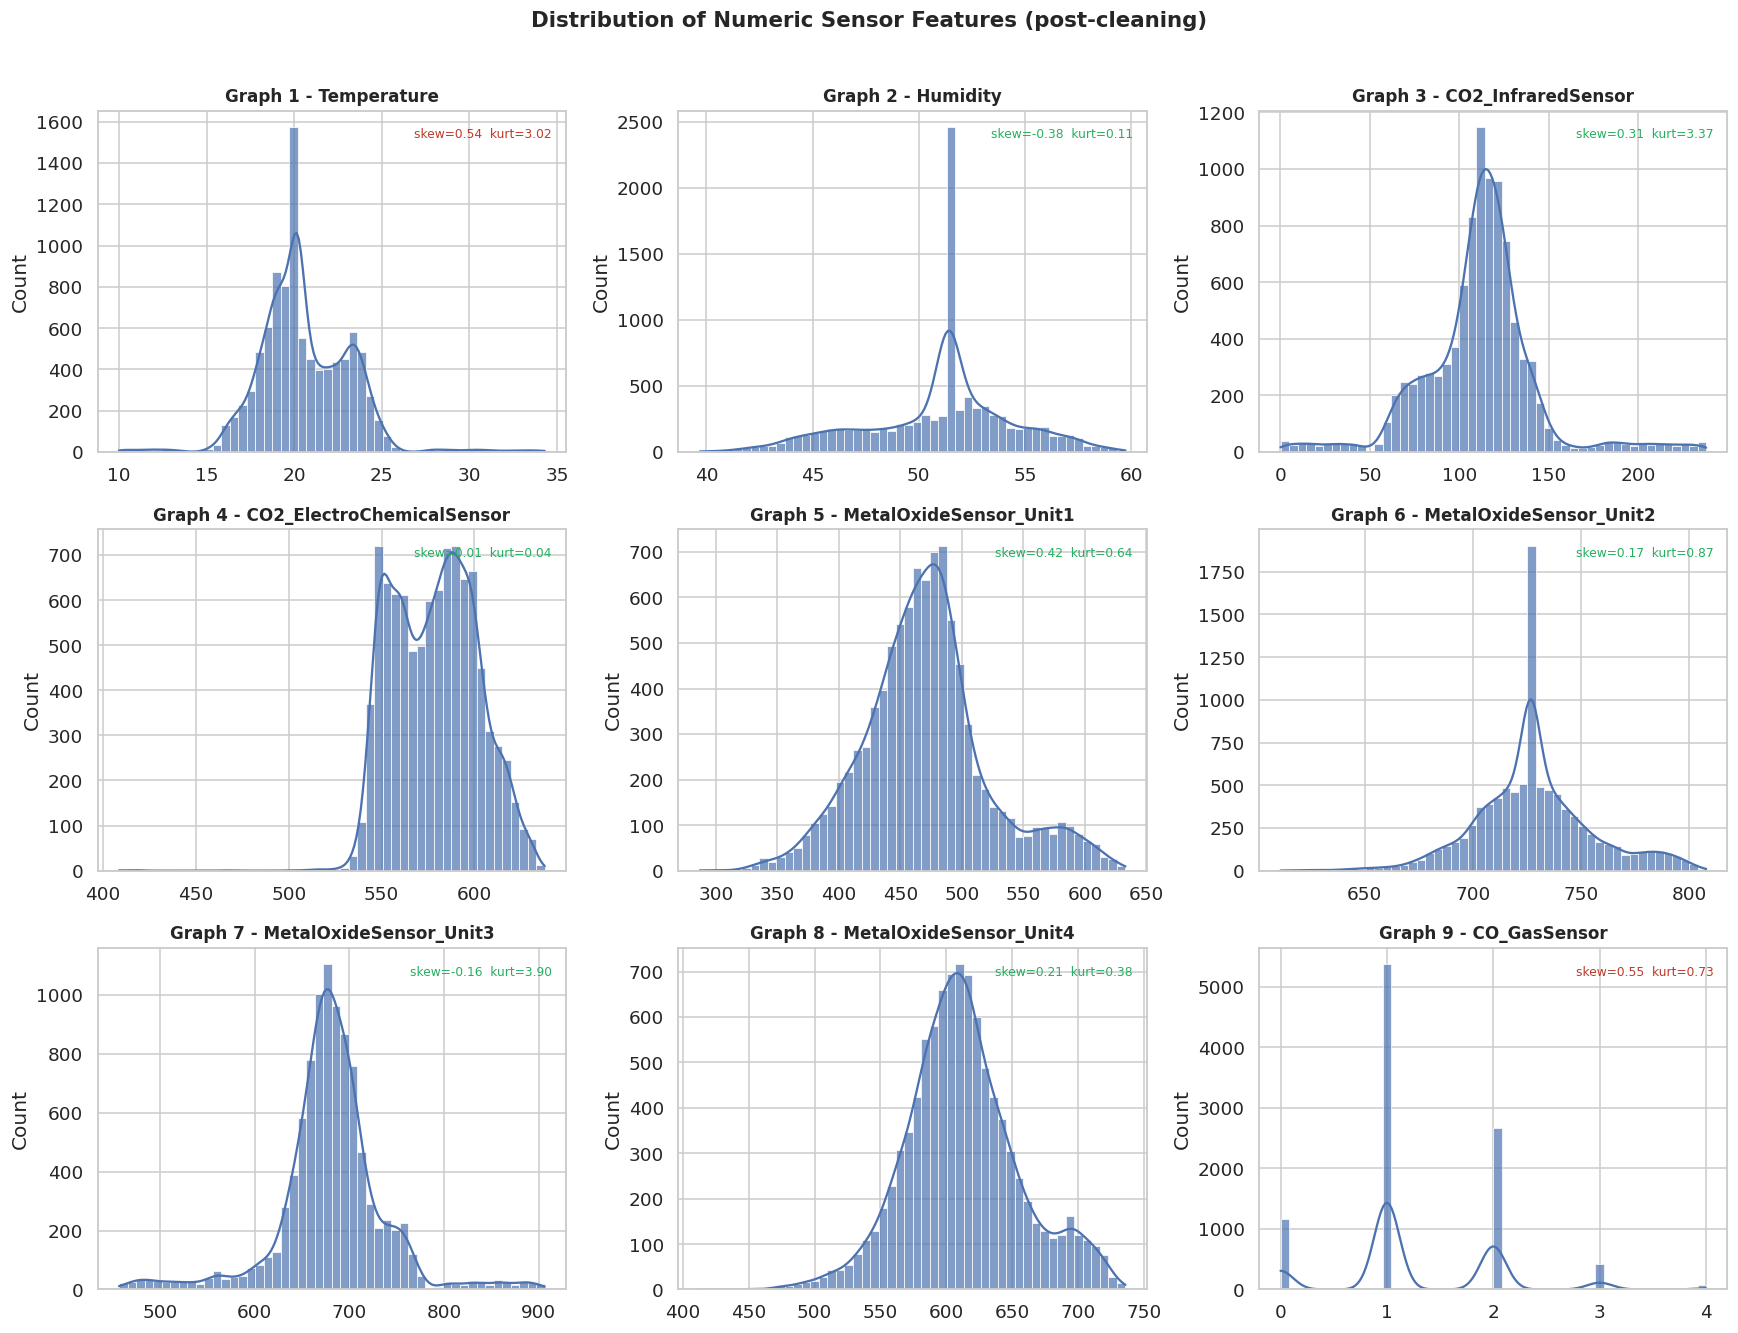

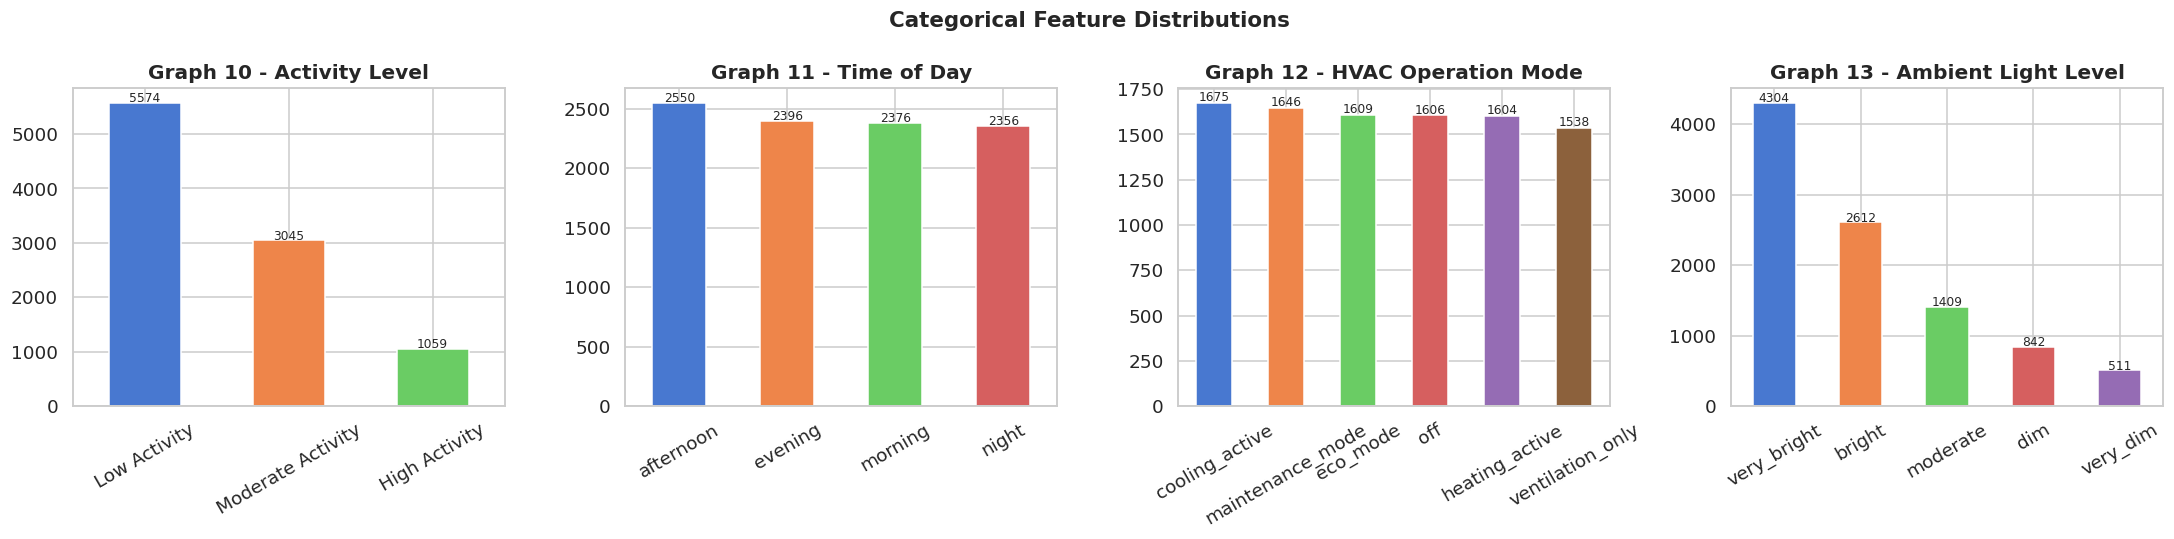

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Temperature,9678.0,20.574,2.559,10.007,18.960,20.210,22.330,34.301,0.538,3.018
Humidity,9678.0,50.996,3.471,39.690,49.200,51.390,52.950,59.730,-0.381,0.110
CO2_InfraredSensor,9678.0,111.238,31.638,0.028,97.735,113.064,124.563,237.874,0.310,3.370
CO2_ElectroChemicalSensor,9678.0,578.642,22.582,408.599,559.363,579.361,595.583,637.896,0.007,0.044
MetalOxideSensor_Unit1,9678.0,471.028,51.503,286.826,440.112,469.244,494.779,632.892,0.421,0.638
MetalOxideSensor_Unit2,9678.0,728.195,26.964,611.169,712.971,726.749,741.277,807.733,0.174,0.868
MetalOxideSensor_Unit3,9678.0,680.514,56.435,456.674,658.459,679.884,703.761,906.213,-0.162,3.901
MetalOxideSensor_Unit4,9678.0,612.300,43.156,412.792,585.366,609.526,636.190,736.112,0.213,0.384
CO_GasSensor,9678.0,1.264,0.750,0.000,1.000,1.000,2.000,4.000,0.547,0.734


In [8]:
# Run the analysis on the data to examine the feature's distribution
desc = univariate_analysis(df)
desc

**In conclusion from the tables and the charts**
- **CO_GasSensor** is right-skewed — most readings are low but occasional high spikes bring the average up. Apply `log1p` transform before using linear models.
- **CO2 sensors** are near-normal — no transformation needed.
- **Activity Level** is imbalanced (Low ~57%, Moderate ~31%, High ~12%) — must use class weights or SMOTE during modelling.
- **Kurtosis > 1** means heavier tails — more frequent extreme values/outliers than a normal distribution, not that the data is more spread out — more extreme values are expected and are real events, not errors.

---
## Part 5: Compare Features with Activity Level

**The main purpose:** Find which features are most useful for predicting activity level

Different graphs we have used for visualization:
- Box plots for numeric features grouped by activity level
- Violin plots for the CO2 sensors
- Stacked bar charts for any of the categorical features as stated in Part 2

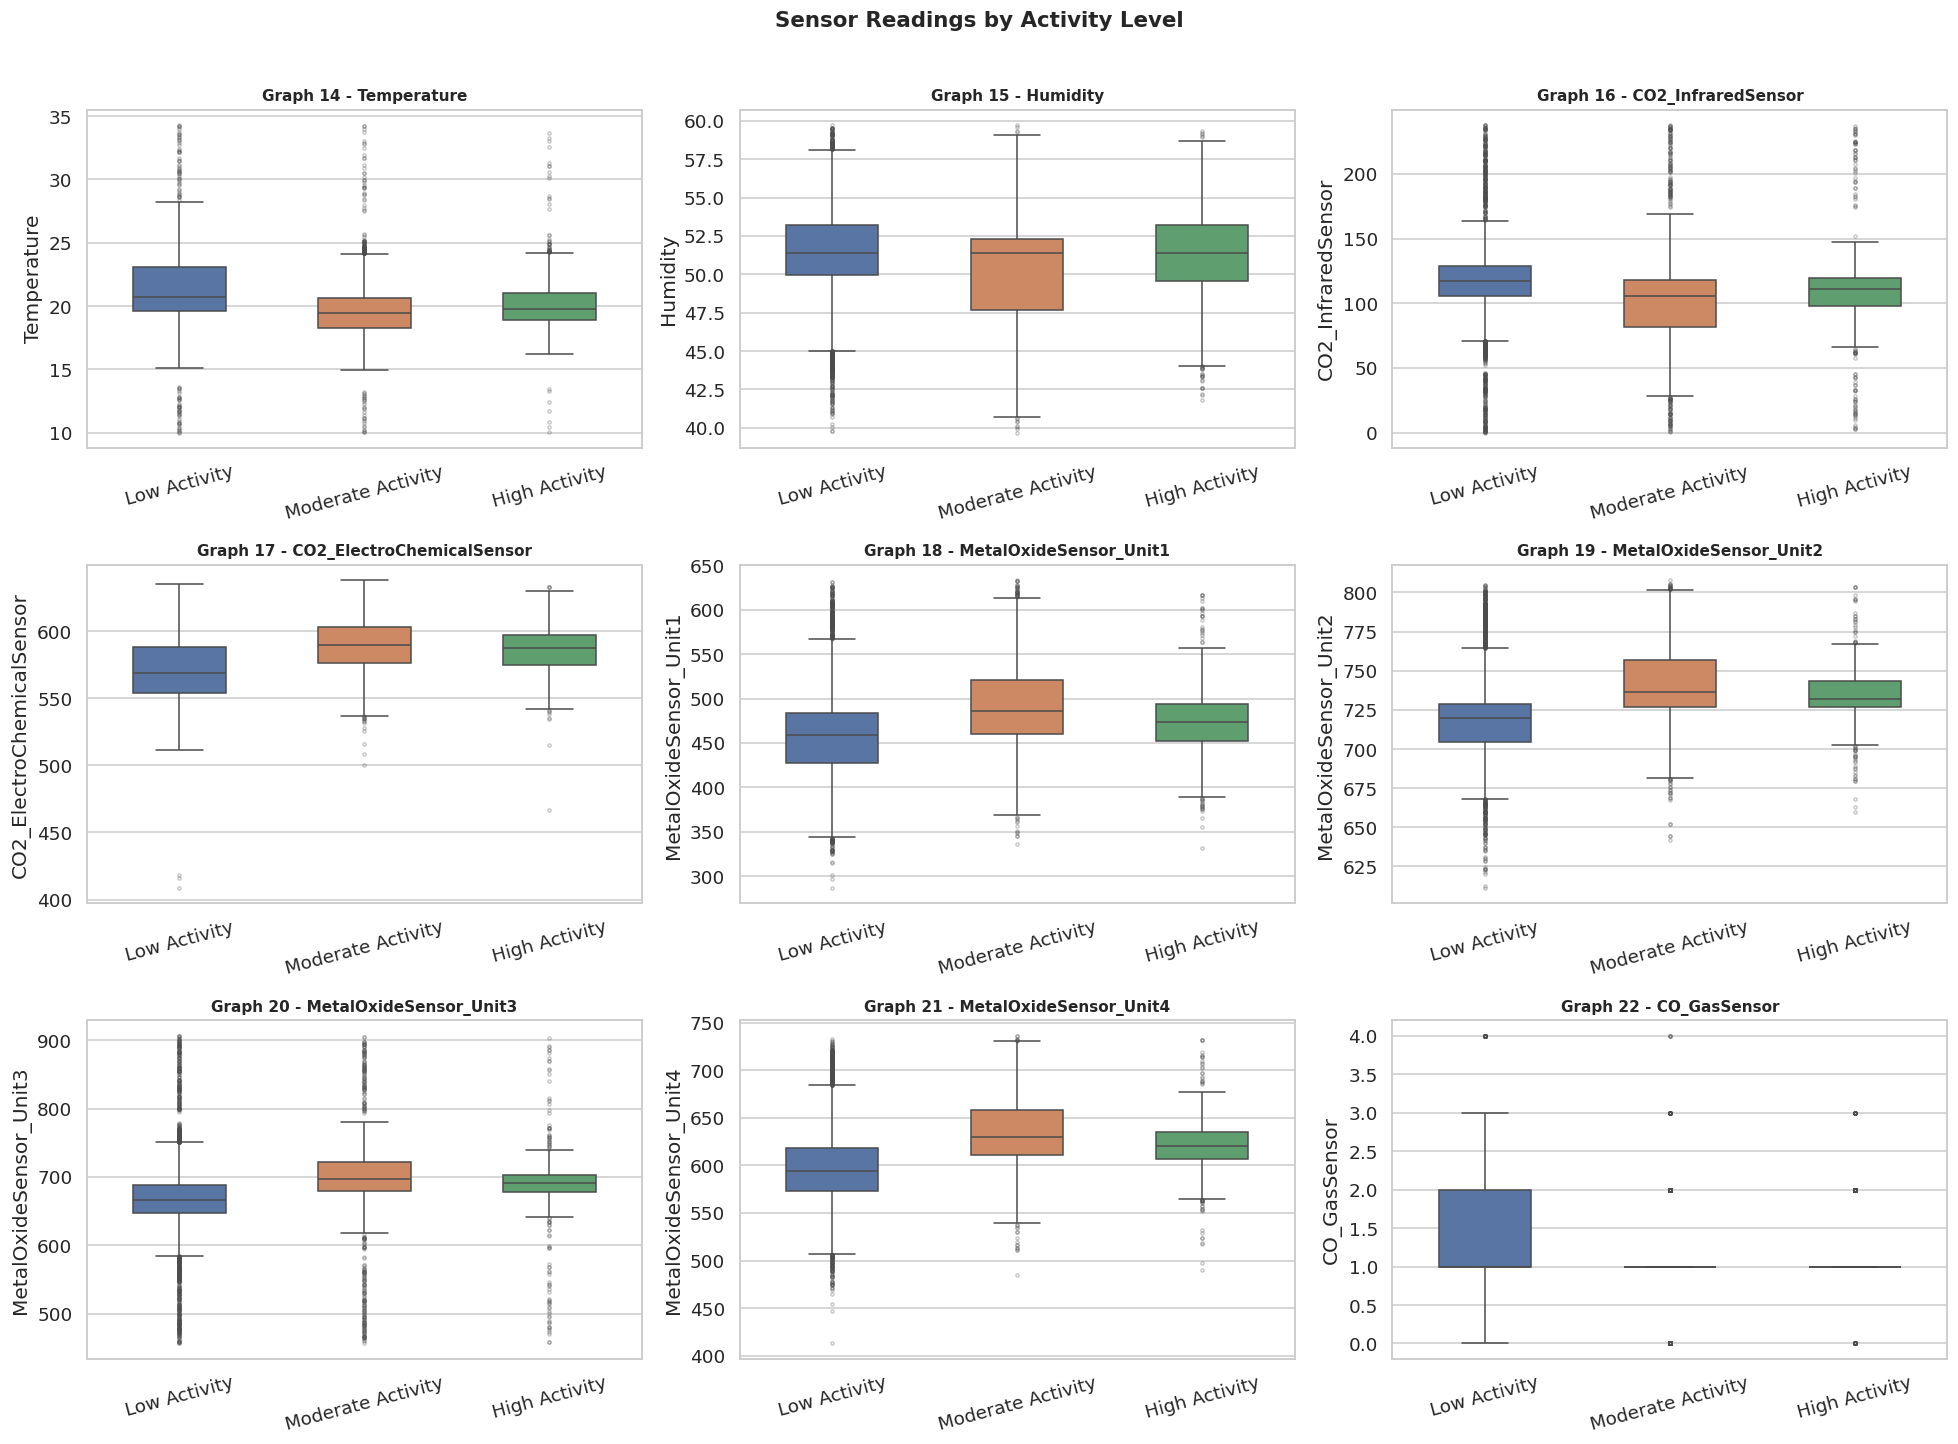

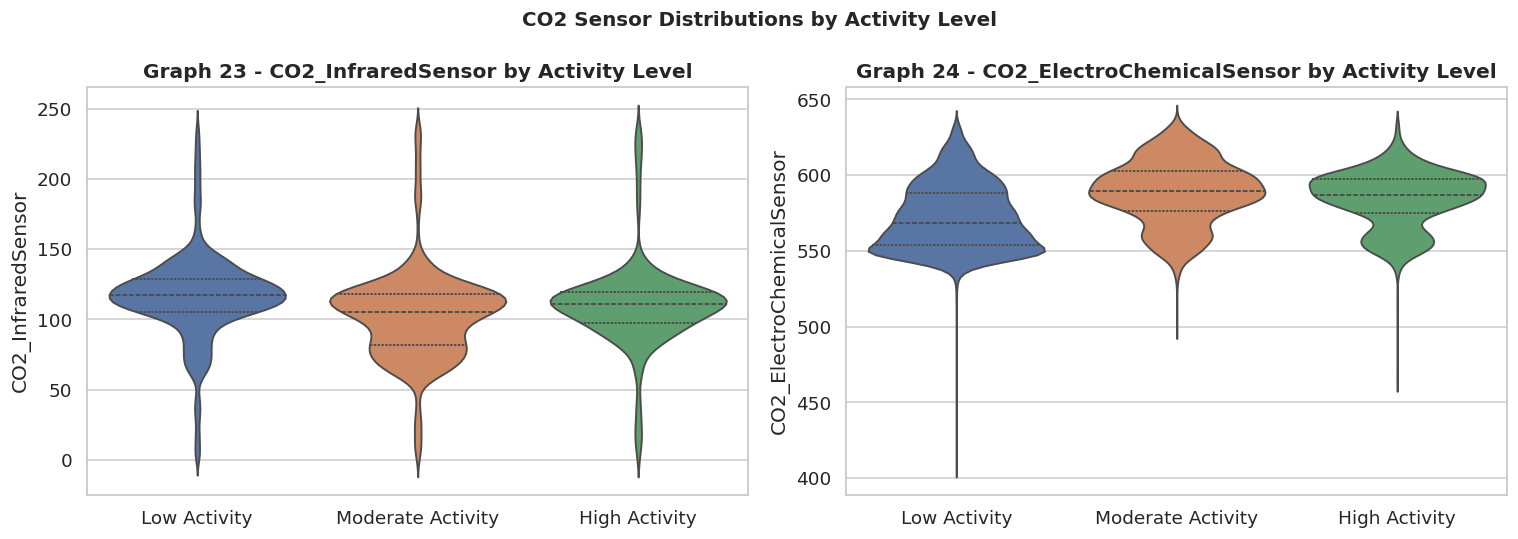

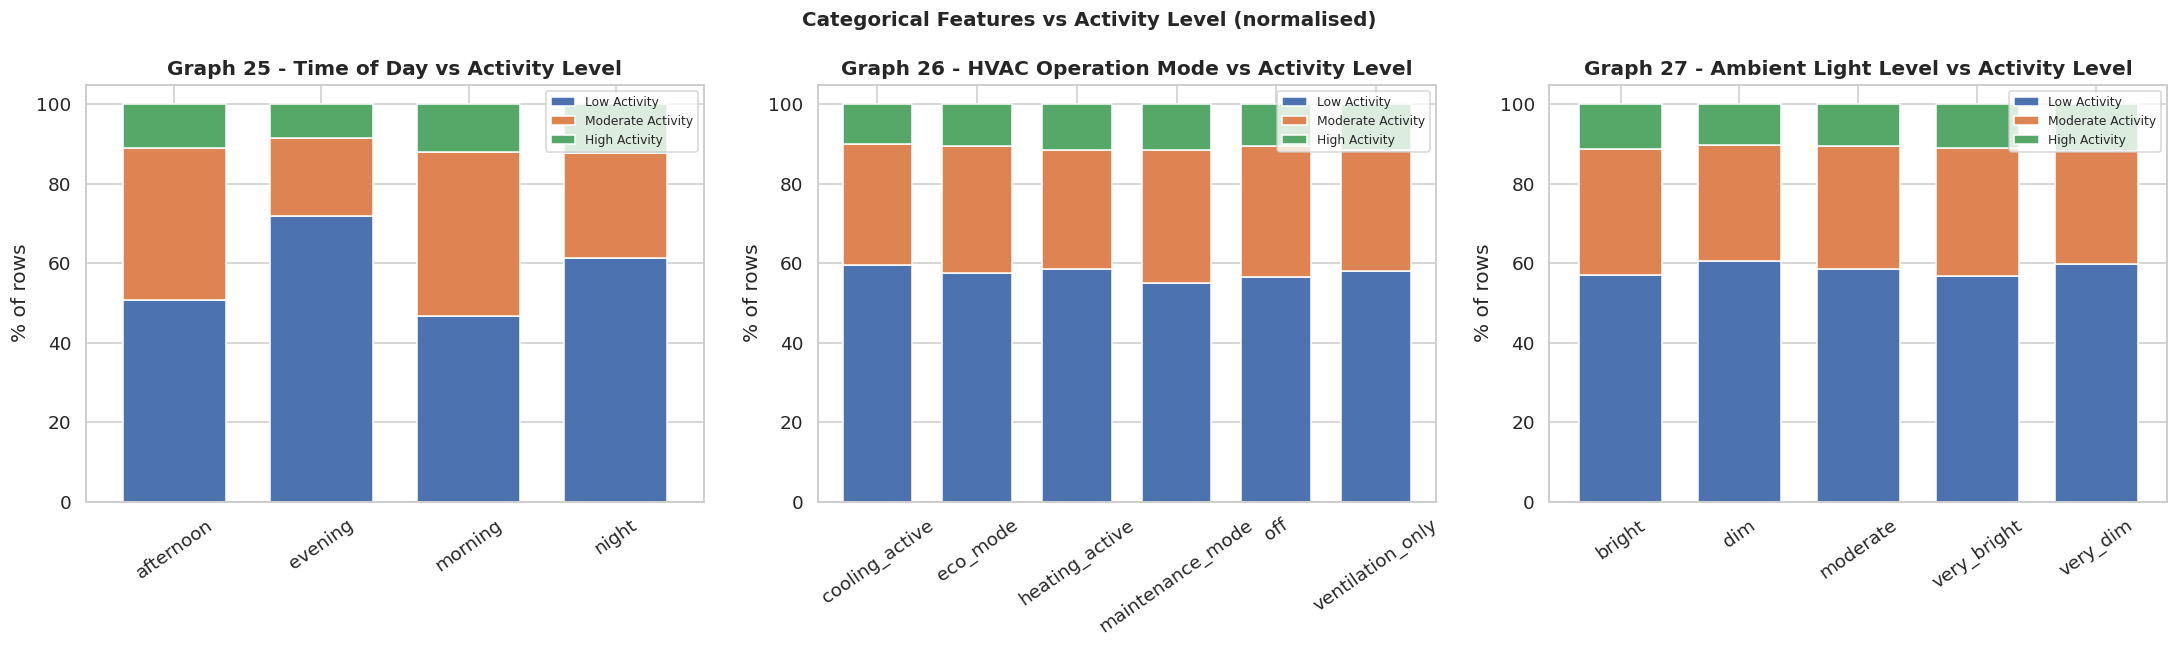

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor
Activity Level,,,,,,,,,
Low Activity,21.12,51.38,116.15,572.07,458.55,719.47,668.57,598.06,1.45
Moderate Activity,19.71,50.22,102.71,588.74,493.03,742.16,699.78,635.33,0.96
High Activity,20.19,51.19,109.94,584.19,473.42,733.97,687.96,621.03,1.15


In [9]:
# Function to compare the feature against the activity
group_means = bivariate_analysis(df)
group_means

**The conclusions that we have made based on the graphs:**
- **CO2 sensors** show clear upward trends with activity level — higher activity produces more CO2 from respiration. Strong candidate features.
- **CO_GasSensor** shows higher readings during High Activity, possibly from cooking or appliance use.
- **Metal Oxide Sensors** show moderate separation — Units 1 and 3 appear more discriminative.
- **Ambient Light Level** shows a clear pattern: High Activity correlates with brighter environments; Low Activity with dim lighting (resting/sleeping).
- **Time of Day** shows High Activity is proportionally more frequent in morning and afternoon periods.

---
## Part 6: Correlation & Multicollinearity Analysis

**Purpose:** Identify which features are strongly correlated with each other and which are most correlated with the target. Highly correlated pairs carry redundant information.

We hVe used a Pearson correlation heatmap and encode the target ordinally for analysis.

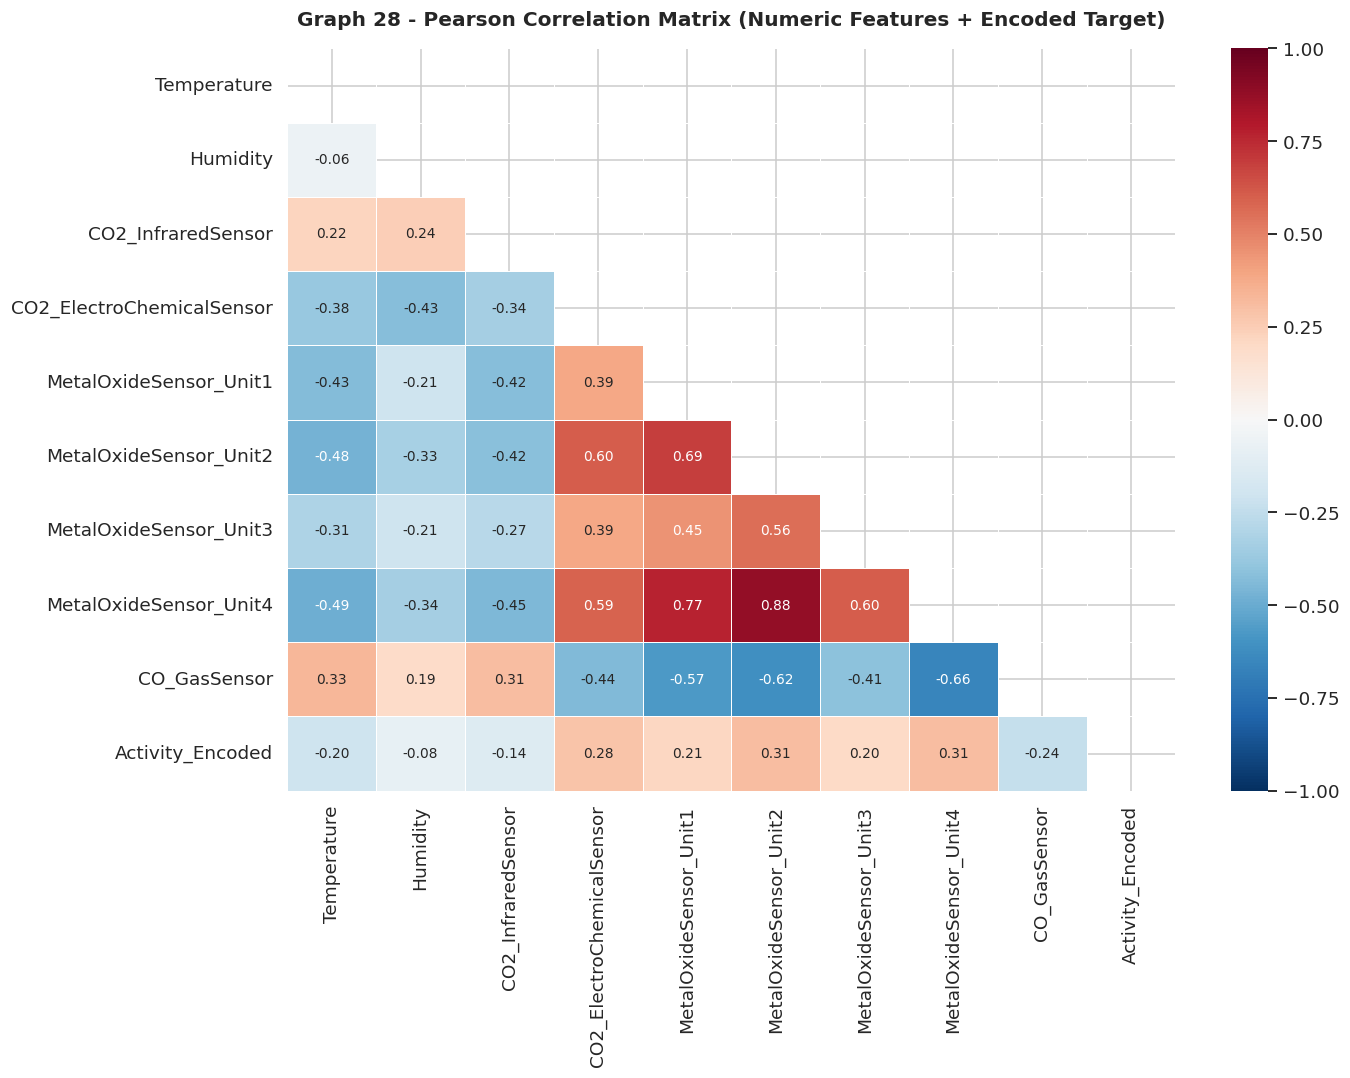

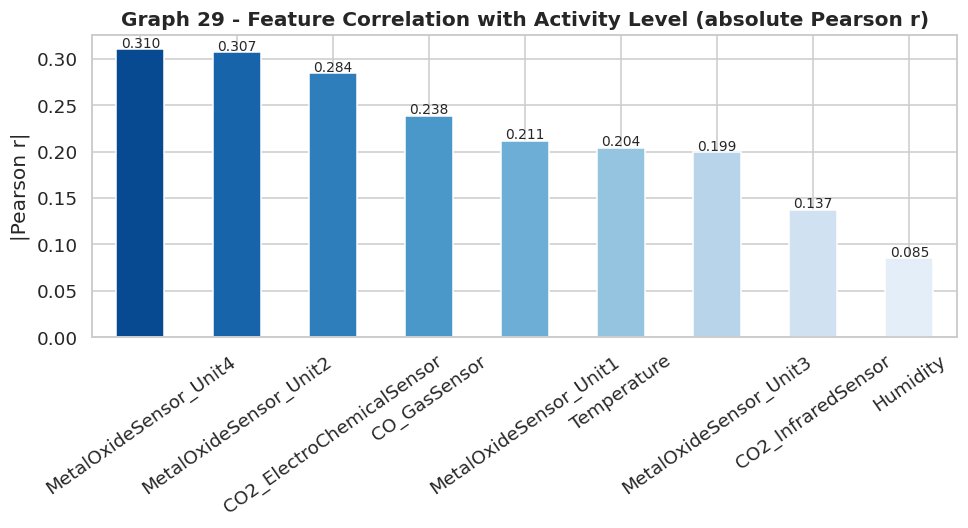

MetalOxideSensor_Unit4       0.310243
MetalOxideSensor_Unit2       0.306844
CO2_ElectroChemicalSensor    0.284381
CO_GasSensor                 0.238452
MetalOxideSensor_Unit1       0.211458
Temperature                  0.204198
MetalOxideSensor_Unit3       0.199296
CO2_InfraredSensor           0.137218
Humidity                     0.084963
Name: Activity_Encoded, dtype: float64

In [10]:
# Function to find which features have the strongest linear relationship with the Activity Level
target_corr = correlation_analysis(df)
target_corr

**Conclusion based on the graphs**
- **CO2_ElectroChemicalSensor** has the highest correlation with the target, confirming it as the top predictor.
- **CO2_InfraredSensor** and **CO2_ElectroChemicalSensor** are highly correlated — they measure the same gas via different technologies. Tree-based models handle this redundancy naturally.
- **Metal Oxide Sensor Units 1–4** show moderate inter-correlation, picking up similar volatile compound signals.
- **Temperature and Humidity** have low target correlation but may contribute non-linearly.
- No near-perfect collinearity (r > 0.95) — all features can be retained for modelling.

---
## Step 7: Session-Level Analysis

**Purpose for analysing this:** The dataset contains a `Session ID` per monitoring session. So by understanding the session-level patterns, it can help detect batch effects and informs if we should use session as a stratification variable in cross-validation.

Unique sessions : 38
Rows per session — min: 56, max: 377, mean: 254.7


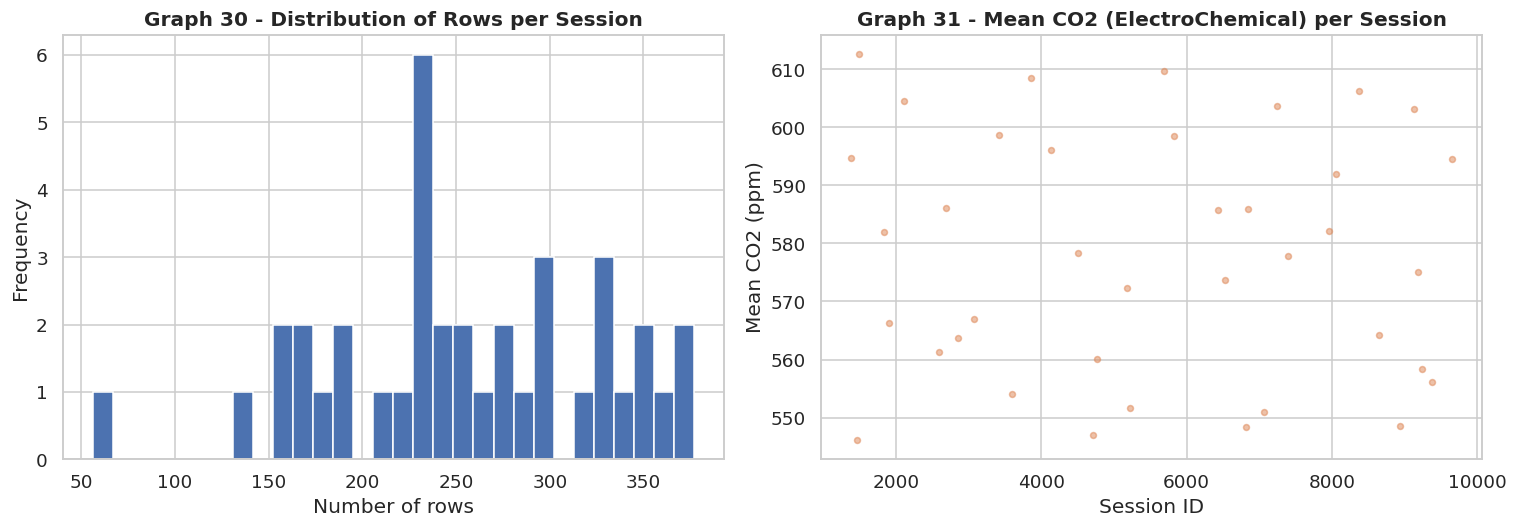

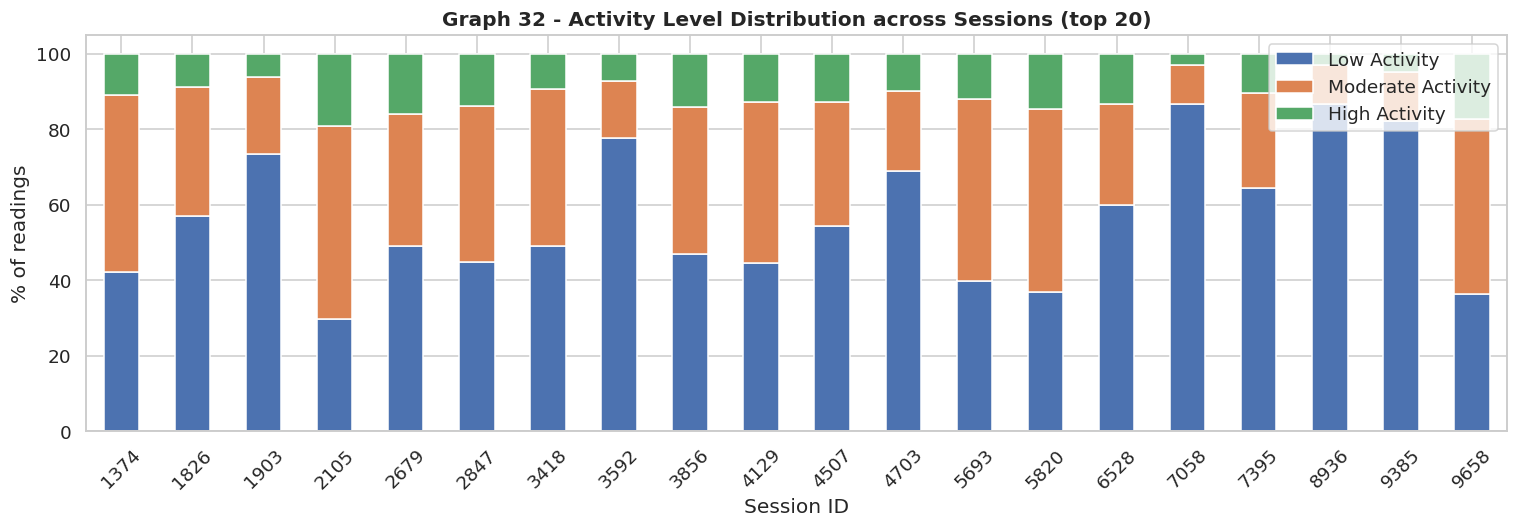

,Session ID,rows,low_pct,mod_pct,high_pct,avg_co2,avg_temp
0,1374,350,42.285714,46.857143,10.857143,594.677999,19.233020
1,1458,174,75.862069,18.965517,5.172414,546.138047,21.482809
2,1482,156,39.102564,43.589744,17.307692,612.591496,20.609478
3,1826,275,57.090909,34.181818,8.727273,581.932384,21.384371
4,1903,297,73.400673,20.538721,6.060606,566.219232,21.214417
5,2105,332,29.819277,50.903614,19.277108,604.545865,20.029036
6,2586,56,44.642857,46.428571,8.928571,561.216055,21.254677
7,2679,269,49.070632,34.944238,15.985130,586.165775,19.250498
8,2847,326,44.785276,41.411043,13.803681,563.714608,20.028599
9,3074,229,79.039301,16.157205,4.803493,566.919004,21.544801


In [11]:
# Function for analysing and examining how sensor readings and activities can vary across different session
session_stats = session_analysis(df)
session_stats.head(10)

**Conclusion for the different sessions**
- Sessions vary in length — some data have only a handful of readings while others have dozens.
- Most of the sessions are dominated by the Low Activity readings and is consistent with the overall class distribution.
- CO2 levels actually vary across the sessions which likely reflects the different residents or monitoring periods.
- Session ID should **not** be used as a predictive feature. It is useful for grouped cross-validation.

---
## Part 8: Final Summary & Implications for Modelling

To help synthesise all the EDA findings into actionable insights that will directly guide the modelling pipeline.

In [12]:
summary(df)

=== Final Cleaned Dataset ===
Shape         : (9678, 14)
Missing values: 0

Activity Level distribution:
  Low Activity          :  5574  (57.6%)
  Moderate Activity     :  3045  (31.5%)
  High Activity         :  1059  (10.9%)

Cleaned dataset saved to data/cleaned_gas_monitoring.csv

=== Next Step: Modelling Pipeline ===
1. Encode features    : ordinal (Time of Day, Ambient Light), one-hot (HVAC)
2. Transform skewed   : log1p on CO_GasSensor for linear models
3. Split data         : GroupShuffleSplit by Session ID (80/20)
4. Handle imbalance   : class_weight="balanced" OR SMOTE on train set only
5. Cross-validate     : StratifiedGroupKFold (5 folds)
6. Train models       : Logistic Regression → Random Forest → XGBoost
7. Evaluate           : macro F1-score (not accuracy — classes are imbalanced)


### Modelling Pipeline (Next Steps)
1. Encode features → ordinal for Time of Day and Ambient Light, one-hot for HVAC
2. log1p transform CO_GasSensor for linear/SVM models
3. GroupShuffleSplit by Session ID to prevent data leakage
4. SMOTE or class_weight='balanced' for class imbalance
5. Evaluate with macro F1-score

---
## EDA Summary

### Key Findings

| Finding | Detail |
|---|---|
| **Label noise** | `Activity Level` and `HVAC Operation Mode` had inconsistent casing — standardised |
| **Missing values** | 4 columns had 8–19% missing — imputed with median/mode |
| **Temperature outliers** | Readings up to 307°C — physically impossible indoors, replaced with median |
| **Class imbalance** | Low:Moderate:High ≈ 57%:31%:12% — models must use class weights or SMOTE |
| **Top predictors** | CO2 sensors (both), CO_GasSensor, Metal Oxide Units 1 & 3, Ambient Light Level |
| **Redundant features** | CO2 sensors are highly correlated — retain both for tree models |
| **Session structure** | Data is grouped by session — use stratified/group cross-validation |
| **Synthetic contamination** | CO2_InfraredSensor averaged 109 ppm (impossible — below atmospheric baseline of 420 ppm), Humidity ranged -49% to 198% — sanitized via physical boundary checks |

### Recommended Models
Based on the given class imbalance, mixed feature types as well as non-linear sensor relationships:
1. **Random Forest** — handles mixed types, robust to outliers, provides feature importance
2. **Gradient Boosted Trees (XGBoost/LightGBM)** — best performance on tabular imbalanced data
3. **Logistic Regression (multinomial)** — interpretable baseline with class weights

### Some Pre-modelling Steps
- Encode categorical features: `Time of Day`, `HVAC Operation Mode`, `Ambient Light Level` → ordinal or one-hot
- Apply `class_weight='balanced'` or SMOTE for the minority class
- Use stratified K-fold cross-validation
- Evaluate with macro F1-score (appropriate for imbalanced multiclass)